## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

- Facilitate the process of visa approvals.
- Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

- case\_id: ID of each visa application
- continent: Information of continent the employee
- education\_of\_employee: Information of education of the employee
- has\_job\_experience: Does the employee has any job experience? Y= Yes; N = No
- requires\_job\_training: Does the employee require any job training? Y = Yes; N = No
- no\_of\_employees: Number of employees in the employer's company
- yr\_of\_estab: Year in which the employer's company was established
- region\_of\_employment: Information of foreign worker's intended region of employment in the US.
- prevailing\_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
- unit\_of\_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- full\_time\_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
- case\_status: Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [1]:
# Dependencies are pinned in requirements.txt at the repo root.
# From the project root run:  pip install -r requirements.txt
# (Uncomment the line below to install directly from the notebook.)
# !pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 imbalanced-learn==0.12.3 -q

**Note**: Dependencies are pinned in `requirements.txt`. Install them with `pip install -r requirements.txt` before running the notebook.

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [3]:
# Load the dataset
# Place EasyVisa.csv inside the ../data/ folder (see data/README.md).
# The path below is relative to the notebooks/ directory.

In [4]:
visa = pd.read_csv('../data/EasyVisa.csv')

In [5]:
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [6]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [8]:
data.shape

(25480, 12)

- The dataset has 25480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


- Only 3 variables are numerical. The rest are all of object types
- All columns display a non-null count of 25,480, meaning there are no missing (null) values in any field.

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [10]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observations

- `case_id` is a unique identifier nad doesn't add any meaning to the analysis so it can be dropped.
- `no_of_employees:` Negative values for number of employees is observed and should be treated.
- `prevailing_wage`: The minimum prevailing wage of `$2` is extremely low and should be verified since it is unlikely to be valid.
- The mean prevailing wage is about $74,000.
- The oldest employer company was established in 1800 and the newest in 2016
- Most employees, about 66% are from the Asian continent.
- About 40% of employees have a Bacholor's degree
- About 90% of the position is full-time
- With respect to the case status, about 67% were certified.

#### Fixing the negative values in number of employees columns

In [11]:
# It was discovered that the no_of_employees column had negative values so we need to treat it
# Checking for number of employees below 0
data[data["no_of_employees"] < 0]["no_of_employees"].unique()

array([-25, -11, -17, -26, -14])

In [12]:
(data['no_of_employees'] < 0).sum()

np.int64(33)

In [13]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])

In [14]:
# Checking if there are still negative number if employees
data[data["no_of_employees"] < 0]["no_of_employees"].unique()

array([], dtype=int64)

Observations:

- The negative values have been converted to positive integers

#### Let's check the count of each unique category in each of the categorical variables

In [15]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [16]:
# case_id is unique for each visa application and might not add value to modeling
data.drop(["case_id"], axis=1, inplace=True)

### Univariate Analysis

In [17]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [18]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

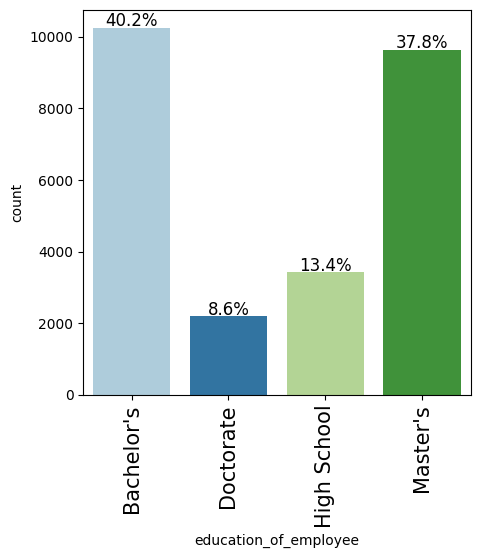

In [19]:
labeled_barplot(data, "education_of_employee", perc=True)

Observations

- "Bachelor's" degree is the most prevalent among employees, representing 40.2% of the dataset.
- "Master's" degree holders make up 37.8%, which is almost as frequent as Bachelor's and together these two categories account for nearly 80% of the employee population.
- There is a relatively small representation from PhD/Doctorate holders and high school educated employees.

#### Observations on region of employment

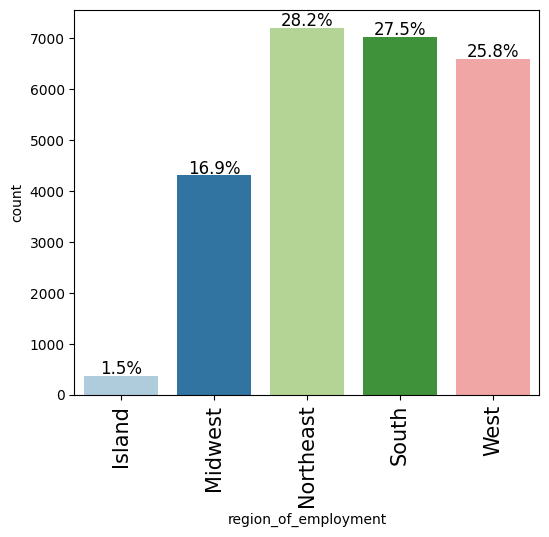

In [20]:
labeled_barplot(data,"region_of_employment",perc=True)

Observations:

- Northeast (28.2%) and South (27.5%) are the top employment destinations, together accounting for more than half the cases.
- West (25.8%) is also prominent, not far behind Northeast and South.
- Midwest lags the top regions but still features a notable share.
- Island regions are extremely rare as destinations for foreign workers.

#### Observations on job experience

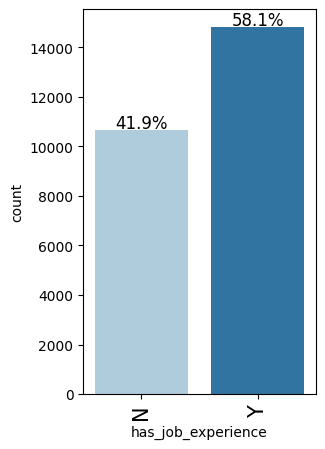

In [21]:
labeled_barplot(data,"has_job_experience",perc=True)

Observations

- Majority have job experience: 58.1% of the cases are for foreign workers who do have prior job experience.
- There is still a substantial share (just over 2/5) of applicants who are new to the job or do not have prior experience, indicating opportunities for entry-level or less-experienced foreign workers.

#### Observations on case status

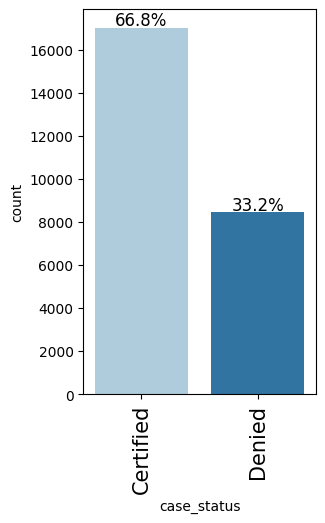

In [22]:
labeled_barplot(data,"case_status",perc=True)

Observations:

- About 66.8% of cases were Certified, meaning they were approved or successful.
- The approval rate for foreign worker certifications is roughly two-thirds, which reflects a generally favorable outcome overall, but there is still a significant denial rate (about one in three).

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [23]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [24]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


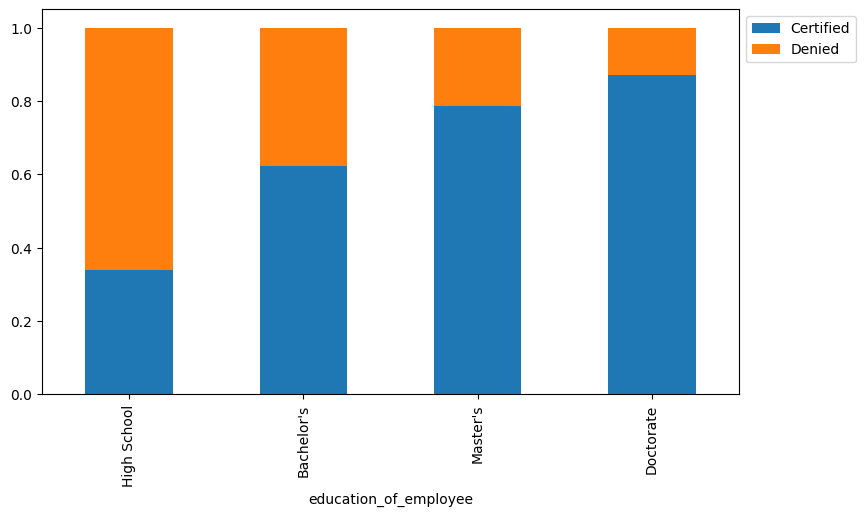

In [25]:
stacked_barplot(data, "education_of_employee", "case_status")

Answer:

- Yes, higher education does increase the chances of visa certification.

Observation:

- The proportion of cases certified increases steadily as education level rises.
- Those with a Master's or Doctorate are far more likely to be approved for a visa compared to applicants with only a High School diploma.

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


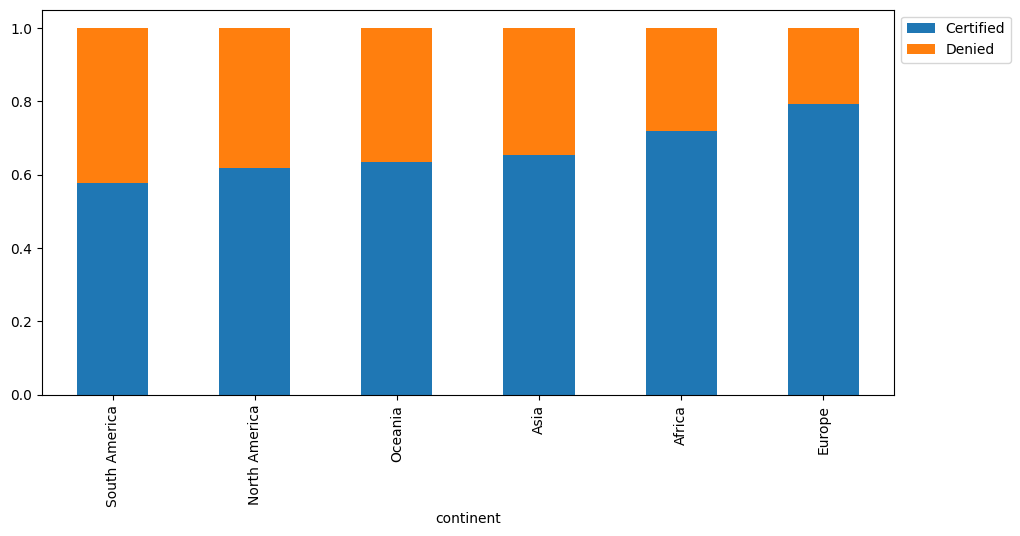

In [26]:
stacked_barplot(data,"continent","case_status")

Observation:

- Europe leads all continents with the highest proportion of certified cases (2,957 certified vs. 775 denied, ~79% certified).
- Africa also has a high certification rate (397 certified vs. 154 denied, ~72% certified).
- South America has the lowest certification rate by proportion (493 certified vs. 359 denied, ~58% certified).
- Visa certification success for foreign workers does vary by continent of origin, with applicants from Europe and Africa most likely to be certified, and those from South America the least likely.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


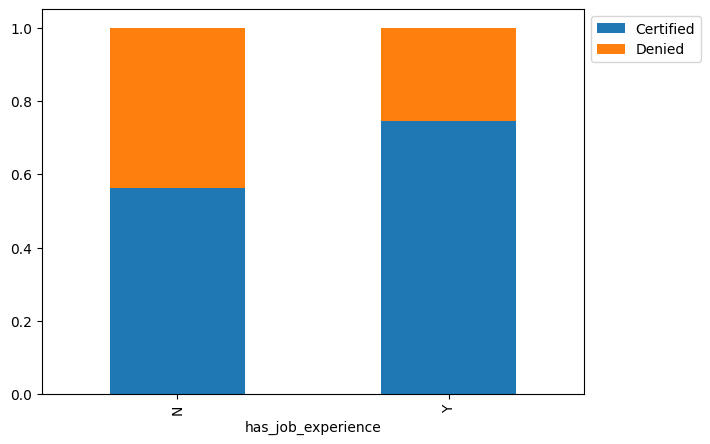

In [27]:
stacked_barplot(data,"has_job_experience","case_status")

Observation:

- Yes, having prior work experience significantly increases the chances of visa certification.
- When applicants have prior job experience, nearly 3 out of 4 are certified.
- Without prior experience, barely more than half receive certification.

#### Is the prevailing wage consistent across all regions of the US?

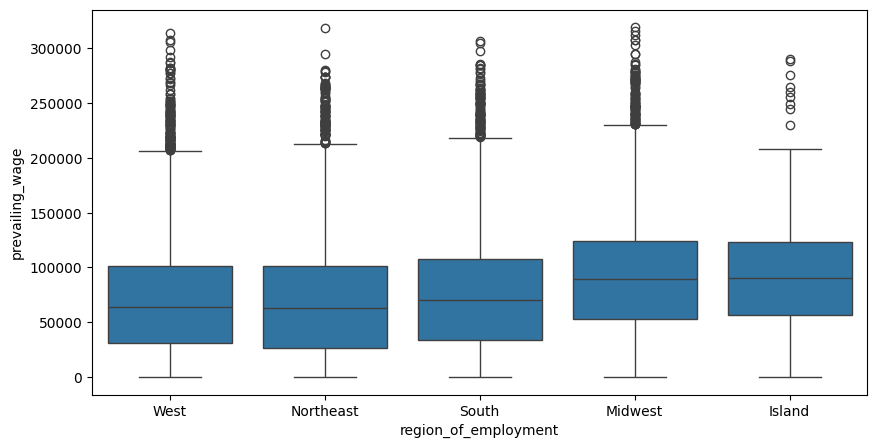

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()

Answer:

- No, the prevailing wage is not completely consistent across all regions.

Observation:

- The median wage is roughly similar across regions, but there are noticeable differences, with the Midwest and South showing slightly higher medians.
- All regions have substantial numbers of high-value outliers (above $200,000), suggesting some exceptionally high wages exist everywhere.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

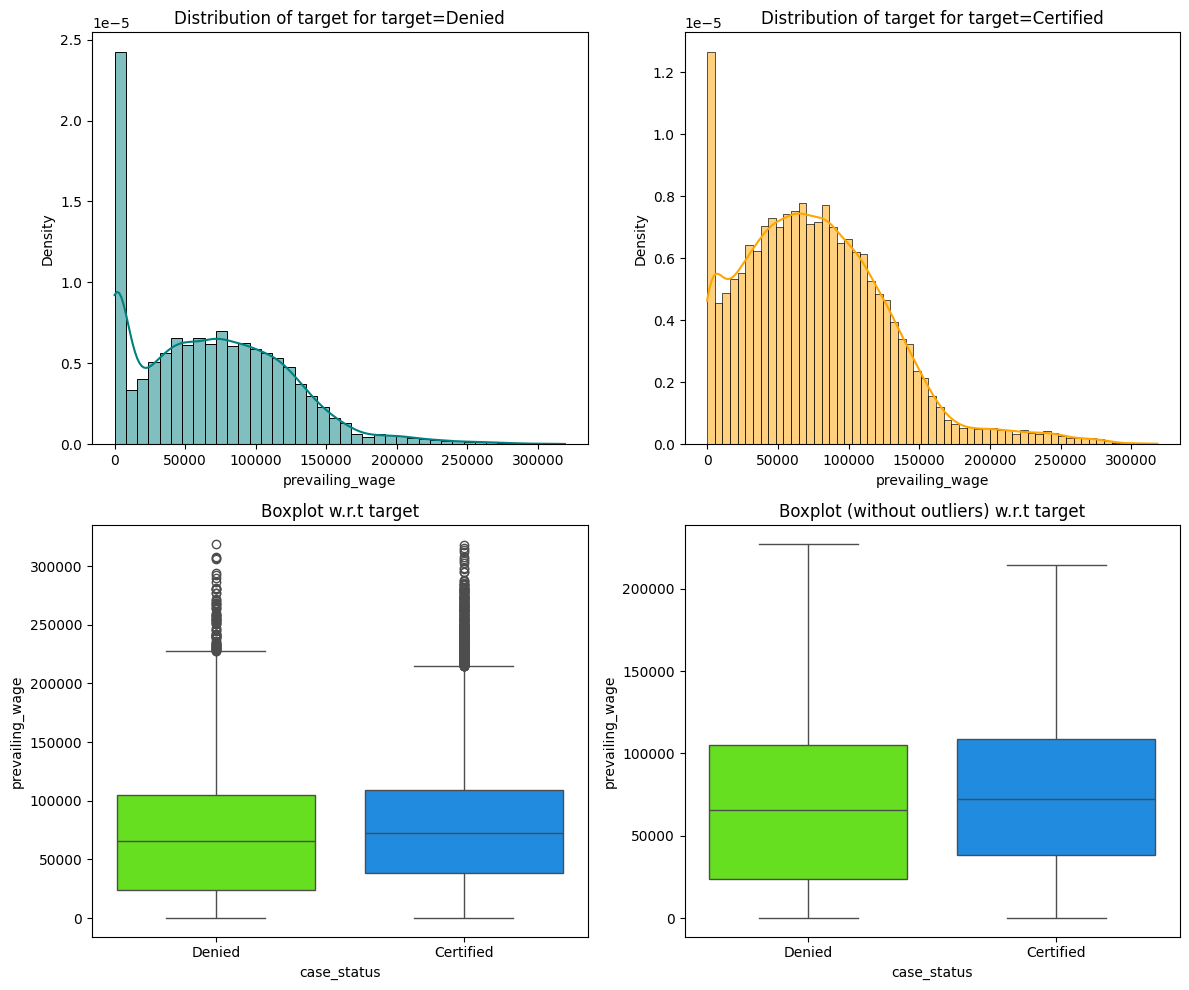

In [29]:
distribution_plot_wrt_target(data,"prevailing_wage","case_status")

Answer:

- Yes, visa status does vary with prevailing wage, but the relationship has some nuances.

Observation:

- Certified cases have a slightly higher median and wider upper range, showing that approvals are more common at higher wages, though some denied cases also occur across the spectrum.
- When removing extreme values, the boxplots for denied and certified become even closer in spread, but the median and central tendency remains slightly higher for certified.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


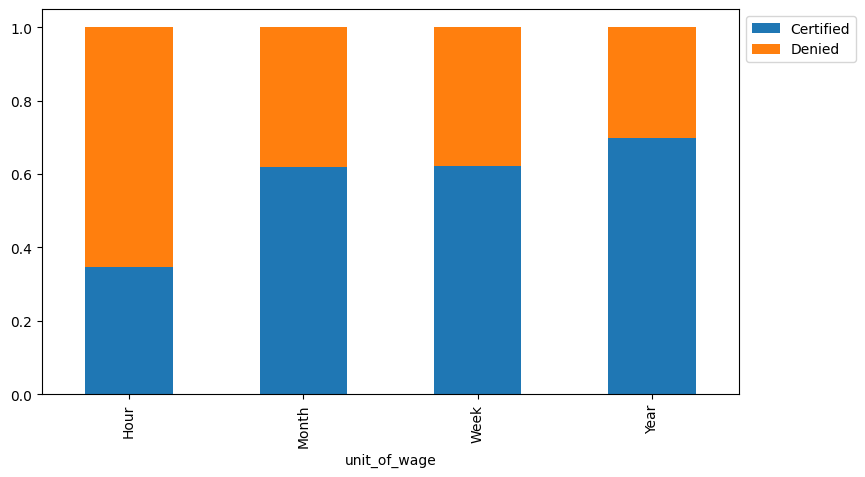

In [30]:
stacked_barplot(data,"unit_of_wage","case_status")

Answer:

- Yes, the unit of wage does have an impact on certification rates.

Obervation:

- The stacked barplot makes it clear: Hourly wage applications see mainly denials, while applications with Year, Month, or Week as their wage unit are more likely to be certified.
- Yearly wage unit: About 70% of applications are certified (16,047 certified vs 6,915 denied).
- Hourly wage unit: Most likely to be denied, with only about 35% certified (747 certified vs 1,410 denied).
- This may reflect a preference for job stability and standardized compensation practices in employment-based visas.

## Data Pre-processing

### Outlier Check

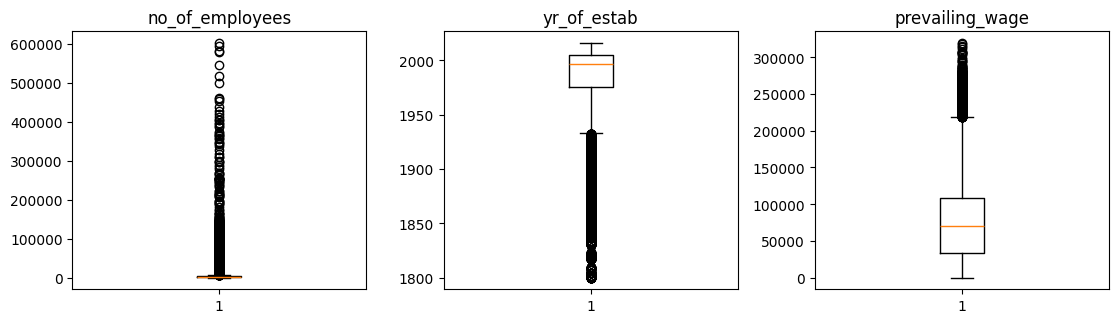

In [31]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Data Preparation for modeling

In [32]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# Drop 'case_status' from features
X = data.drop(['case_status'], axis=1)
y = data["case_status"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into train and validation with a ratio of 7:3
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Split the validation set into validation and test with a ratio of 9:1
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.1, random_state=1, stratify=y_val
)

In [33]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. Predicting an applicant should be certified, but in reality, the applicant should be denied. Loss of resources: Visa is granted to unqualified candidates, potentially harming compliance and wasting resources.
2. Predicting an applicant should be denied, but in reality, the applicant should be certified. Loss of opportunity: Qualified candidates miss out on career opportunities in the US. OFLC’s goal of facilitating qualified approvals is compromised.

**Which case is more important for OFLC?**

- Predicting an applicant should be denied, but in reality, the applicant should be certified. This case is more important: Losing out on qualified candidates means the process fails to facilitate deserving approvals and the candidate loses a valuable opportunity.

**How to reduce this loss (i.e., need to reduce False Negatives):**

- Company would want Recall to be maximized—greater recall means fewer qualified candidates are missed by the model, and visa approvals are facilitated for all eligible applicants.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

- The `model_performance_classification_sklearn` function will be used to check the model performance of models.
- The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [34]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [35]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [36]:
scorer = metrics.make_scorer(metrics.recall_score)

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [37]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # 5 splits gives a good balance between bias and variance
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:



Bagging: 0.7751203687750448


Random forest: 0.8387487214396122


GBM: 0.8727446688039722


Adaboost: 0.8874346097620529


...

Bagging: 0.7638223770134959


Random forest: 0.8289072703526339


GBM: 0.8746190683500218


Adaboost: 0.8833260774923813
Xgboost: 0.8493687418371789


dtree: 0.7414018284719199


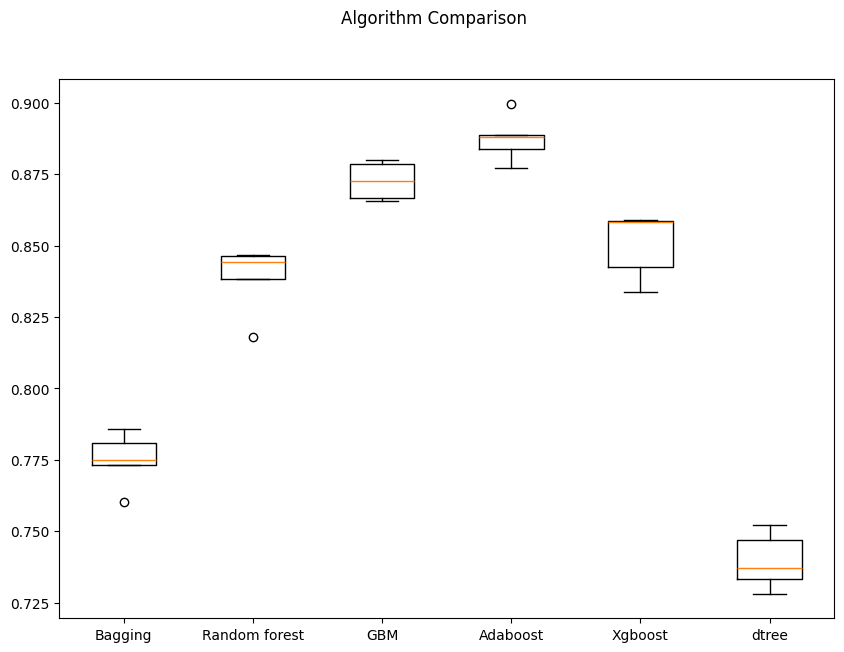

In [38]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

Observation:

- On the validation set, the model with the best performance is Adaboost, with a performance score of 0.8831.
- The second best performer is GBM

### Model Building with Oversampled data

In [39]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1) ## Complete the code to set the k-nearest neighbors
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 



After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [40]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# Loop through all models to get the mean cross-validated score
print("\nCross-Validation performance on training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  ## 5-fold cross-validation (standard choice)

    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  ## Fit model on oversampled training data

    scores = recall_score(y_val, model.predict(X_val))

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:



Bagging: 0.7438098298435637


Random forest: 0.8191058057828453


GBM: 0.8592301753992826


Adaboost: 0.8623363504363578


...

Bagging: 0.7485851110143665


Random forest: 0.8186765346103614


GBM: 0.8528515454941228


Adaboost: 0.8561166739225076


Xgboost: 0.8410970831519373
dtree: 0.7248585111014366


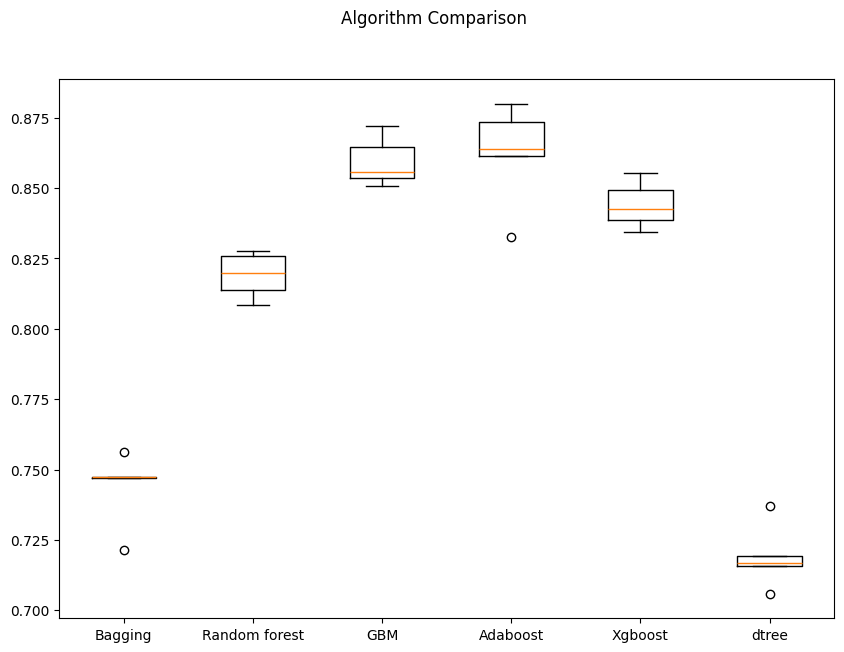

In [41]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

Observation:

- The model with the best performance on the validation set is Adaboost, with a score of 0.8739.
- GBM has the second best performance.

### Model Building with Undersampled data

In [42]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [43]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store names of the models


# Loop through all models to get the mean cross-validated score
print("\nCross-Validation performance on training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  ## 5 splits for cross-validation

    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold, n_jobs=-1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)  ## Fit the model on undersampled training data

    scores = recall_score(y_val, model.predict(X_val))

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:



Bagging: 0.6040899760520013


Random forest: 0.6831018360132285


GBM: 0.7187274774774776


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


...

Bagging: 0.6055724858511101


Random forest: 0.6702220287331302


GBM: 0.7085328689595124


Adaboost: 0.7085328689595124
Xgboost: 0.6852416195037004


dtree: 0.6216804527644754


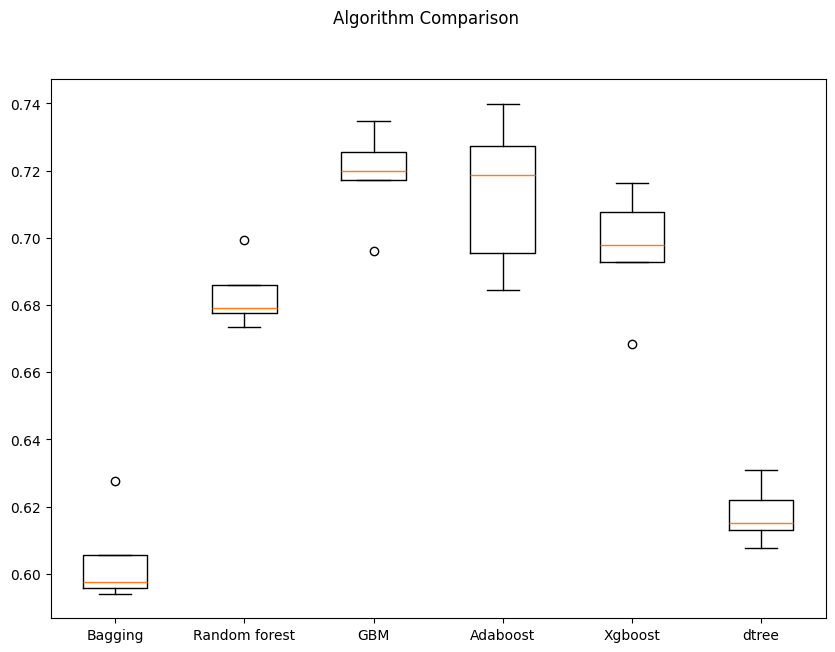

In [44]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

Observation

- The model with the best performance on validation in this result is Adaboost, with a score of 0.7168.
- GBM performed best on the training data but was behind Adaboost on the validation set.

- After building 18 models, it was observed that the Adaboost model consistently exhibited the strongest performance on both the training and validation datasets, regardless of whether it was trained on an oversampled or undersampled dataset. The GBM model also showed strong performance, though not always matching Adaboost, across both sampling strategies.
- Since models trained with undersampling or oversampling can sometimes overfit, it is important to tune them to achieve generalized performance.
  Therefore, we will tune these top-performing models (Adaboost and GBM), using the same (undersampled or oversampled) data as they were originally trained on

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100
- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)
- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)
- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01
- Use 1.0 for faster training, suitable for fewer estimators
- Use 0.1 or 0.01 when using more estimators to improve generalization
- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data

---

**Best practices for hyperparameter tuning in Random Forest:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
- Higher values generally improve performance but increase training time
- Use 100-150 for large datasets or when variance is high

`min_samples_leaf`:

- Try values like: 1, 2, 4, 5, 10
- Higher values reduce model complexity and help prevent overfitting
- Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
- Works well in noisy datasets to smooth predictions

`max_features`:

- Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
- `"sqrt"` balances between diversity and performance for classification tasks
- Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
- Higher values (closer to `1.0`) may capture more interactions but risk overfitting

`max_samples` (for bootstrap sampling):

- Try float values between `0.5` to `1.0` or fixed integers
- Use `0.6–0.9` to introduce randomness and reduce overfitting
- Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

- Start with 100 (default) and increase: 100, 200, 300, 500
- Typically, higher values lead to better performance, but they also increase training time
- Use 200–500 for larger datasets or complex problems
- Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization

`learning_rate`:

- Common values to try: 0.1, 0.05, 0.01, 0.005
- Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
- Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
- Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting

`subsample`:

- Common values: 0.7, 0.8, 0.9, 1.0
- Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
- `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
- Reducing `subsample` can help reduce overfitting, especially in smaller datasets

`max_features`:

- Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
- `"sqrt"` (default) works well for classification tasks
- Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

- Start with 50 and increase in steps: 50,75,100,125.
- Use more estimators (e.g., 150-250) when using lower learning rates
- Monitor validation performance
- High values improve learning but increase training time

`subsample`:

- Common values: 0.5, 0.7, 0.8, 1.0
- Use `0.7–0.9` to introduce randomness and reduce overfitting
- `1.0` uses the full dataset in each boosting round; may overfit on small datasets
- Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

- Try values: 0 (default), 1, 3, 5, 8
- Controls minimum loss reduction needed for a split
- Higher values make the algorithm more conservative (i.e., fewer splits)
- Use values > 0 to regularize and reduce overfitting, especially on noisy data

`colsample_bytree`:

- Try values: 0.3, 0.5, 0.7, 1.0
- Fraction of features sampled per tree
- Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
- Use `1.0` when you want all features considered for every tree

`colsample_bylevel`:

- Try values: 0.3, 0.5, 0.7, 1.0
- Fraction of features sampled at each tree level (i.e., per split depth)
- Lower values help in regularization and reducing overfitting
- Often used in combination with `colsample_bytree` for fine control over feature sampling

---

### Tuning AdaBoost using Oversampled data

In [45]:
%%time

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125],  ## Number of estimators to try
    "learning_rate": [1.0, 0.5, 0.1, 0.01],  ## Common learning rates to tune
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,         ## using previously defined recall scorer
    cv=5,                   ## 5-fold cross-validation (standard practice)
    random_state=1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)  ## Fit on oversampled training data

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


CPU times: user 2.24 s, sys: 320 ms, total: 2.56 s
Wall time: 3min 37s


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [1.0, 0.5, 0.1, 0.01],
                                        'n_estimators': [50, 75, 100, 125]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [46]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 50, 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.931923507999745:


In [47]:
tuned_ada1 = randomized_cv.best_estimator_
tuned_ada1

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [48]:
tuned_ada1.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [49]:
tuned_ada1_train_perf = model_performance_classification_sklearn(tuned_ada1, X_train_over, y_train_over)
tuned_ada1_train_perf

,Accuracy,Recall,Precision,F1
0,0.650718,0.931923,0.596465,0.72738


In [50]:
## Complete the code to check the model performance for validation data.
tuned_ada1_val_perf = model_performance_classification_sklearn(tuned_ada1, X_val, y_val)
tuned_ada1_val_perf

,Accuracy,Recall,Precision,F1
0,0.70548,0.930344,0.714716,0.808398


### Tuning AdaBoost using Undersampled data

In [51]:
%%time

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125],  ## Number of estimators to try
    "learning_rate": [1.0, 0.5, 0.1, 0.01],  ## Common learning rates to tune
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,         ## using previously defined recall scorer
    cv=5,                   ## 5-fold cross-validation (standard practice)
    random_state=1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)  ## Fit on oversampled training data

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


CPU times: user 1.5 s, sys: 184 ms, total: 1.68 s
Wall time: 1min 56s


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [1.0, 0.5, 0.1, 0.01],
                                        'n_estimators': [50, 75, 100, 125]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [52]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 50, 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9095074980043336:


In [53]:
tuned_ada2 = randomized_cv.best_estimator_
tuned_ada2

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [54]:
tuned_ada2.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [55]:
tuned_ada2_train_perf = model_performance_classification_sklearn(tuned_ada2, X_train_un, y_train_un)
tuned_ada2_train_perf

,Accuracy,Recall,Precision,F1
0,0.599865,0.928415,0.560265,0.698818


In [56]:
tuned_ada2_val_perf = model_performance_classification_sklearn(tuned_ada2, X_val, y_val)
tuned_ada2_val_perf

,Accuracy,Recall,Precision,F1
0,0.70548,0.930344,0.714716,0.808398


### Tuning Gradient Boosting model with Undersampled data

In [57]:
%%time

# Define Gradient Boosting model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid with best-practice tuning ranges
param_grid = {
    "n_estimators": [100, 200, 300, 500],       # Number of boosting stages
    "learning_rate": [0.1, 0.05, 0.01, 0.005],  # Learning rate shrinks contribution of each tree
    "subsample": [0.7, 0.8, 0.9, 1.0],          # Fraction of samples for fitting individual base learners
    "max_features": ["sqrt", "log2", 0.3, 0.5], # Number of features to consider at each split
    "init": [
        None,  # Default initialization
        DecisionTreeClassifier(max_depth=1, random_state=1),  # Weak learner initializer
    ],
}

scorer = metrics.make_scorer(metrics.recall_score)

# Initialize RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,           # Number of random combinations to try
    scoring=scorer,
    cv=5,                # 5-fold cross-validation
    random_state=1,
    n_jobs=-1            # Use all available CPU cores
)

# Fit parameters using undersampled data
randomized_cv.fit(X_train_un, y_train_un)

CPU times: user 1.67 s, sys: 159 ms, total: 1.83 s
Wall time: 2min 49s


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'init': [None,
                                                 DecisionTreeClassifier(max_depth=1,
                                                                        random_state=1)],
                                        'learning_rate': [0.1, 0.05, 0.01,
                                                          0.005],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [58]:
print("Best parameters are {} with CV score={}:".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

Best parameters are {'subsample': 0.9, 'n_estimators': 100, 'max_features': 'log2', 'learning_rate': 0.005, 'init': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9029219409282699:


In [59]:
tuned_gbm = randomized_cv.best_estimator_

In [60]:
tuned_gbm.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=DecisionTreeClassifier(max_depth=1,
                                                       random_state=1),
                           learning_rate=0.005, max_features='log2',
                           random_state=1, subsample=0.9)

In [61]:
tuned_gbm_train_perf = model_performance_classification_sklearn(tuned_gbm, X_train_un, y_train_un)
tuned_gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.650346,0.900219,0.600248,0.720249


In [62]:
tuned_gbm_val_perf = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
tuned_gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.725978,0.897693,0.744539,0.813974


## Model Performance Summary and Final Model Selection

In [63]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        tuned_ada1_train_perf.T,
        tuned_ada2_train_perf.T,
        tuned_gbm_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost tuned with oversampled data",
    "AdaBoost tuned with undersampled data",
    "Gradient Boosting tuned with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost tuned with oversampled data,AdaBoost tuned with undersampled data,Gradient Boosting tuned with undersampled data
Accuracy,0.650718,0.599865,0.650346
Recall,0.931923,0.928415,0.900219
Precision,0.596465,0.560265,0.600248
F1,0.727380,0.698818,0.720249


In [64]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        tuned_ada1_val_perf.T,
        tuned_ada2_val_perf.T,
        tuned_gbm_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "AdaBoost tuned with oversampled data",
    "AdaBoost tuned with undersampled data",
    "Gradient Boosting tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost tuned with oversampled data,AdaBoost tuned with undersampled data,Gradient Boosting tuned with undersampled data
Accuracy,0.705480,0.705480,0.725978
Recall,0.930344,0.930344,0.897693
Precision,0.714716,0.714716,0.744539
F1,0.808398,0.808398,0.813974


- Gradient Boosting tuned with undersampled data is the best model, as it slightly outperforms AdaBoost on most key metrics (F1, precision, and accuracy) while keeping recall nearly as high. This is important for both not missing certified cases and minimizing false positives.

In [65]:
# Let's check the performance on test set
ada_test = model_performance_classification_sklearn(tuned_gbm, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.738562,0.900196,0.755337,0.821429


- The Gradient Boosting model trained on undersampled data has given ~90% recall on the test set.
- This performance is in line with what we achieved with this model on the train and validation sets.
- So, this is a generalized model.

### Feature Importance

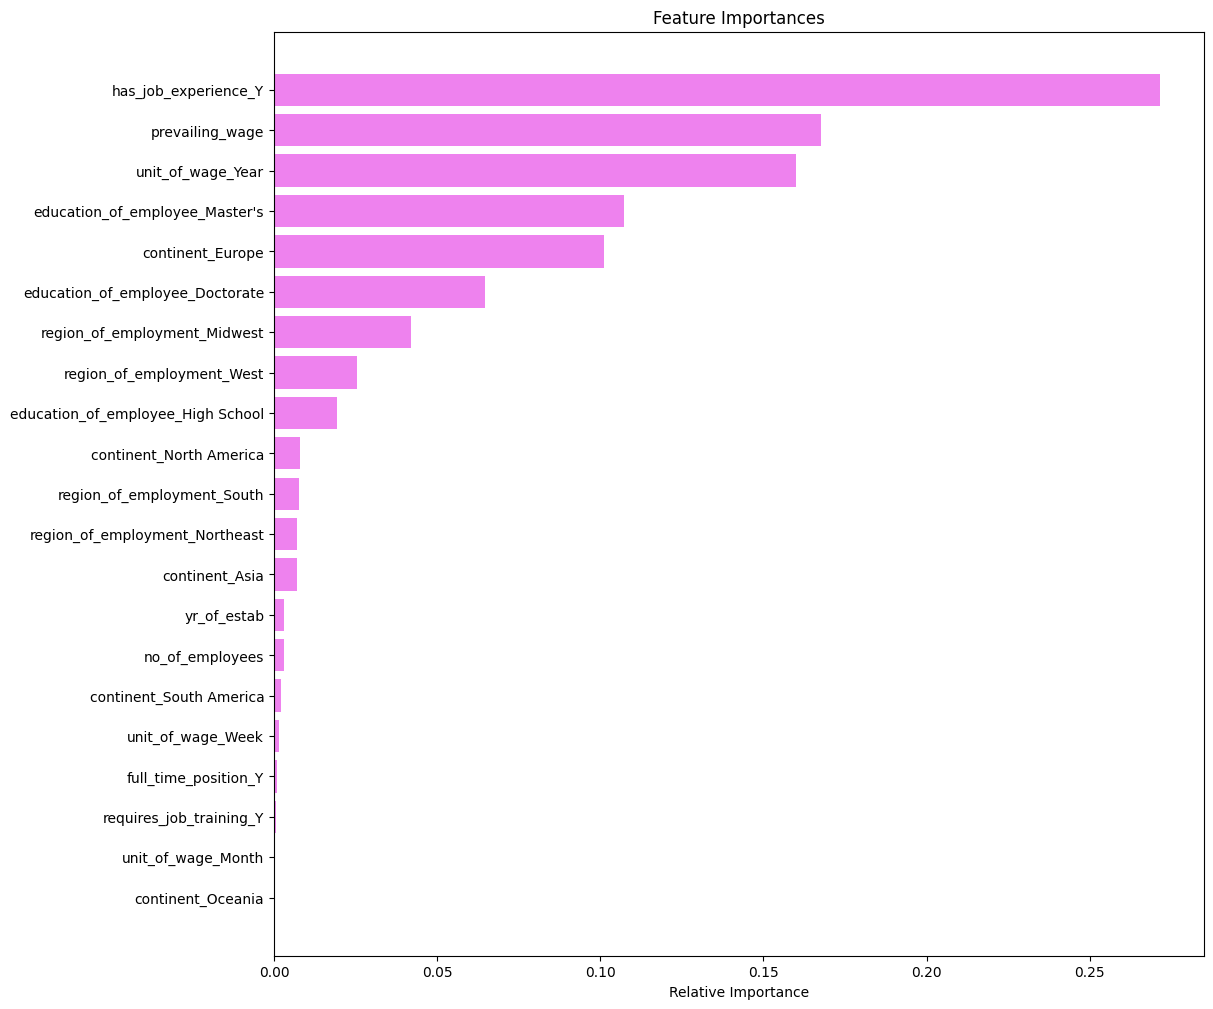

In [66]:
feature_names = X_train.columns
importances = tuned_gbm.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

***Observations***

Most Influential Features:

- `has_job_experience_Y:` Prior work experience is the single most important predictor for visa certification.
- `prevailing_wage:` Higher wages are strongly associated with certification outcomes.
- `unit_of_wage_Year:` Jobs with annual salary structures are more likely to be certified.
- `education_of_employee_Master's:` Having a Master's degree substantially increases the chance of certification.

Highly Relevant but Lesser Contributers:

- `continent_Europe & education_of_employee_Doctorate:` Applicants from Europe and those with Doctorate degrees get a significant boost.
- Jobs in the Midwest and West regions has a meaningful impact.

## Actionable Insights and Recommendations

- The most influential factors in visa certification are applicants' prior job experience, prevailing wage (especially for yearly wage units), and advanced education (Master's or Doctorate). Jobs offering higher annual wages and requiring skilled, experienced workers are most frequently certified.
- Certain regions (e.g., Midwest, West in the US; applicants from Europe) show higher approval rates, but profile factors (experience and wage) still dominate.
- The system ensures foreign workers are not underpaid, maintaining fair competition and wage standards for local employees.
- For OFLC Use the developed classification model to automatically shortlist and prioritize cases with high probability of visa certification. This prioritizes candidates with strong profiles, i.e. experience, advanced degrees, and competitive yearly wages.
- For employers, target and invest in applicants with skilled experience and advanced education. These applicants are statistically more likely to receive certifications. Structuring wages yearly is favored in certification, while hourly wage applications are less likely to be approved.
- For applicants, emphasize job experience and highest degree. Applicants should showcase their most advanced qualification and relevant experience.
- Implementing the "Gradient Boosting model trained on undersampled data" machine learning-based visa screening tool will greatly improve OFLC’s efficiency and effectiveness, ensuring the best talent is certified without compromising US labor standards. Employers and applicants should align profiles and expectations with the strongest approval drivers: experience, education, competitive wages, and transparent reporting.

Power Ahead

---